In [168]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/InflAdj_Data_2019_2025-20th-20th.csv")

In [113]:
# df = df.loc[~df["symbol"].isin(df.loc[(df["close"] < 5) & (df["report_date"] == df.groupby('symbol')['report_date'].transform('min'))]["symbol"]),:]

In [114]:
# df.loc[df["symbol"].isin(df.loc[(df["close"] < 4.65) & (df["report_date"] == "2019-01-02")]["symbol"]),:]["symbol"].unique()

In [115]:
# df.to_csv("data/InflAdj_Data_2019_2025_more_than_five.csv")

In [170]:
df = df.loc[:, ["report_date", "close (%)", "close"]].groupby("report_date").mean()

In [171]:
df.loc[df["close (%)"] < 0,:]

,close (%),close
report_date,,
2019-01-03,-1.057445,73.184108
2020-03-09,-4.344127,62.537411
2020-03-10,-2.150726,63.907997
2020-03-11,-7.266728,61.038041
2020-03-12,-17.143065,55.683521
...,...,...
2025-05-08,-2.054362,49.280953
2025-05-09,-2.003395,49.194372
2025-05-21,-0.153125,49.698047


Line will not start in the centre, because then we can't do negative values, instead start a set distance from the centre, probably one so that we avoid negative values from crossing the centre

In [172]:
df.reset_index(inplace=True)

In [173]:
df["change_day"] = df["close"] - df["close"].shift(1, fill_value=0)
df.loc[0, "change_day"] = 0

In [174]:
df["report_date"] = pd.to_datetime(df["report_date"])
df

,report_date,close (%),close,change_day
0,2019-01-02,0.000000,74.174000,0.000000
1,2019-01-03,-1.057445,73.184108,-0.989891
2,2019-01-04,1.996026,75.116281,1.932173
3,2019-01-07,3.524115,76.182796,1.066514
4,2019-01-08,4.649826,76.920149,0.737353
...,...,...,...,...
1755,2025-12-24,13.823307,52.183552,0.171267
1756,2025-12-26,13.722539,52.154776,-0.028775
1757,2025-12-29,13.093518,51.931574,-0.223203
1758,2025-12-30,12.781311,51.720889,-0.210685


In [175]:
# 2. Create the target date (1 year ago)
df['Target_Date'] = df['report_date'] - pd.DateOffset(years=1)

# 3. Create a reference DataFrame to look up historical prices
df_lookup = df[['report_date', 'close']].rename(
    columns={'report_date': 'Matched_Date', 'close': 'close_1yr_ago'}
)

# 4. Use merge_asof to match Target_Date to Matched_Date, grouped by Ticker
df = pd.merge_asof(
    df,
    df_lookup,
    left_on='Target_Date',
    right_on='Matched_Date',
    direction='backward',
    tolerance=pd.Timedelta(days=4)
)
df.drop(columns=["Target_Date", "Matched_Date"], inplace=True)
df

,report_date,close (%),close,change_day,close_1yr_ago
0,2019-01-02,0.000000,74.174000,0.000000,NaN
1,2019-01-03,-1.057445,73.184108,-0.989891,NaN
2,2019-01-04,1.996026,75.116281,1.932173,NaN
3,2019-01-07,3.524115,76.182796,1.066514,NaN
4,2019-01-08,4.649826,76.920149,0.737353,NaN
...,...,...,...,...,...
1755,2025-12-24,13.823307,52.183552,0.171267,54.166147
1756,2025-12-26,13.722539,52.154776,-0.028775,54.250469
1757,2025-12-29,13.093518,51.931574,-0.223203,53.695533
1758,2025-12-30,12.781311,51.720889,-0.210685,53.504532


In [176]:
# 2. Create the target date (1 year ago)
df['Target_Date'] = df['report_date'] - pd.DateOffset(months=1)

# 3. Create a reference DataFrame to look up historical prices
df_lookup = df[['report_date', 'close']].rename(
    columns={'report_date': 'Matched_Date', 'close': 'close_1mo_ago'}
)

# 4. Use merge_asof to match Target_Date to Matched_Date, grouped by Ticker
df = pd.merge_asof(
    df,
    df_lookup,
    left_on='Target_Date',
    right_on='Matched_Date',
    direction='backward',
    tolerance=pd.Timedelta(days=4)
)
df.drop(columns=["Target_Date", "Matched_Date"], inplace=True)
df

,report_date,close (%),close,change_day,close_1yr_ago,close_1mo_ago
0,2019-01-02,0.000000,74.174000,0.000000,NaN,NaN
1,2019-01-03,-1.057445,73.184108,-0.989891,NaN,NaN
2,2019-01-04,1.996026,75.116281,1.932173,NaN,NaN
3,2019-01-07,3.524115,76.182796,1.066514,NaN,NaN
4,2019-01-08,4.649826,76.920149,0.737353,NaN,NaN
...,...,...,...,...,...,...
1755,2025-12-24,13.823307,52.183552,0.171267,54.166147,50.329600
1756,2025-12-26,13.722539,52.154776,-0.028775,54.250469,51.484675
1757,2025-12-29,13.093518,51.931574,-0.223203,53.695533,51.705985
1758,2025-12-30,12.781311,51.720889,-0.210685,53.504532,51.705985


In [177]:
df["change_year"] = df["close"] - df["close_1yr_ago"]
df["change_month"] = df["close"] - df["close_1mo_ago"]
df

,report_date,close (%),close,change_day,close_1yr_ago,close_1mo_ago,change_year,change_month
0,2019-01-02,0.000000,74.174000,0.000000,NaN,NaN,NaN,NaN
1,2019-01-03,-1.057445,73.184108,-0.989891,NaN,NaN,NaN,NaN
2,2019-01-04,1.996026,75.116281,1.932173,NaN,NaN,NaN,NaN
3,2019-01-07,3.524115,76.182796,1.066514,NaN,NaN,NaN,NaN
4,2019-01-08,4.649826,76.920149,0.737353,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1755,2025-12-24,13.823307,52.183552,0.171267,54.166147,50.329600,-1.982596,1.853952
1756,2025-12-26,13.722539,52.154776,-0.028775,54.250469,51.484675,-2.095692,0.670101
1757,2025-12-29,13.093518,51.931574,-0.223203,53.695533,51.705985,-1.763959,0.225588
1758,2025-12-30,12.781311,51.720889,-0.210685,53.504532,51.705985,-1.783643,0.014903


In [178]:
df["close (%)"] = (df["close"] - df.loc[0,"close"]) / df.loc[0,"close"] * 100
df

,report_date,close (%),close,change_day,close_1yr_ago,close_1mo_ago,change_year,change_month
0,2019-01-02,0.000000,74.174000,0.000000,NaN,NaN,NaN,NaN
1,2019-01-03,-1.334553,73.184108,-0.989891,NaN,NaN,NaN,NaN
2,2019-01-04,1.270367,75.116281,1.932173,NaN,NaN,NaN,NaN
3,2019-01-07,2.708221,76.182796,1.066514,NaN,NaN,NaN,NaN
4,2019-01-08,3.702307,76.920149,0.737353,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1755,2025-12-24,-29.647111,52.183552,0.171267,54.166147,50.329600,-1.982596,1.853952
1756,2025-12-26,-29.685905,52.154776,-0.028775,54.250469,51.484675,-2.095692,0.670101
1757,2025-12-29,-29.986823,51.931574,-0.223203,53.695533,51.705985,-1.763959,0.225588
1758,2025-12-30,-30.270865,51.720889,-0.210685,53.504532,51.705985,-1.783643,0.014903


In [179]:
df['month'] = pd.DatetimeIndex(df['report_date']).month
df["day"] = pd.DatetimeIndex(df['report_date']).day

In [180]:
month_to_degree = {m: (m - 1) * 30 for m in range(1, 13)}
df["month_rotation"] = df["month"].map(month_to_degree.get)

In [181]:
# 2. Convert report_date to datetime if not already
df['report_date'] = pd.to_datetime(df['report_date'])
df['year'] = df['report_date'].dt.year

# 3. Calculate min and max day for each month per year
# We group by year and month to handle the "dynamic" nature of banking days
month_bounds = df.groupby(['year', 'month'])['day'].agg(['min', 'max']).reset_index()
month_bounds.rename(columns={'min': 'min_day', 'max': 'max_day'}, inplace=True)

# 4. Merge these bounds back into the main dataframe
df = df.merge(month_bounds, on=['year', 'month'])

# 5. Calculate the rotation
# (day - min) / (max - min) gives a value between 0 and 1
# We use .fillna(0) for cases where a month might only have 1 data point
df['day_progress'] = (df['day'] - df['min_day']) / (df['max_day'] - df['min_day']).replace(0, 1)
df['day_degrees'] = df['month'].map(month_to_degree) + (df['day_progress'] * 30)

# Cleanup (optional)
df = df.drop(columns=['min_day', 'max_day', 'day_progress'])

In [182]:
shift_zero = abs(df["close (%)"].min())
df["distance_from_center"] = df["close (%)"] + shift_zero

In [183]:
from numpy import cos, sin, radians
df["x"] = df["distance_from_center"] * sin(radians(df["day_degrees"]))
df["y"] = df["distance_from_center"] * cos(radians(df["day_degrees"]))

In [184]:
df["cont_time"] = df.index

In [185]:
# plt.figure(figsize=(13,10))
# plt.scatter(df["x"], df["y"], c = df["cont_time"])
# plt.colorbar()
# plt.axis("off")

In [186]:
df

,report_date,close (%),close,change_day,close_1yr_ago,close_1mo_ago,change_year,change_month,month,day,month_rotation,year,day_degrees,distance_from_center,x,y,cont_time
0,2019-01-02,0.000000,74.174000,0.000000,NaN,NaN,NaN,NaN,1,2,0,2019,0.000000,41.157068,0.000000e+00,41.157068,0
1,2019-01-03,-1.334553,73.184108,-0.989891,NaN,NaN,NaN,NaN,1,3,0,2019,1.034483,39.822515,7.189616e-01,39.816025,1
2,2019-01-04,1.270367,75.116281,1.932173,NaN,NaN,NaN,NaN,1,4,0,2019,2.068966,42.427435,1.531733e+00,42.399776,2
3,2019-01-07,2.708221,76.182796,1.066514,NaN,NaN,NaN,NaN,1,7,0,2019,5.172414,43.865290,3.954591e+00,43.686667,3
4,2019-01-08,3.702307,76.920149,0.737353,NaN,NaN,NaN,NaN,1,8,0,2019,6.206897,44.859375,4.850152e+00,44.596407,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1755,2025-12-24,-29.647111,52.183552,0.171267,54.166147,50.329600,-1.982596,1.853952,12,24,330,2025,353.000000,11.509957,-1.402711e+00,11.424164,1755
1756,2025-12-26,-29.685905,52.154776,-0.028775,54.250469,51.484675,-2.095692,0.670101,12,26,330,2025,355.000000,11.471163,-9.997777e-01,11.427512,1756
1757,2025-12-29,-29.986823,51.931574,-0.223203,53.695533,51.705985,-1.763959,0.225588,12,29,330,2025,358.000000,11.170245,-3.898359e-01,11.163440,1757
1758,2025-12-30,-30.270865,51.720889,-0.210685,53.504532,51.705985,-1.783643,0.014903,12,30,330,2025,359.000000,10.886203,-1.899904e-01,10.884545,1758


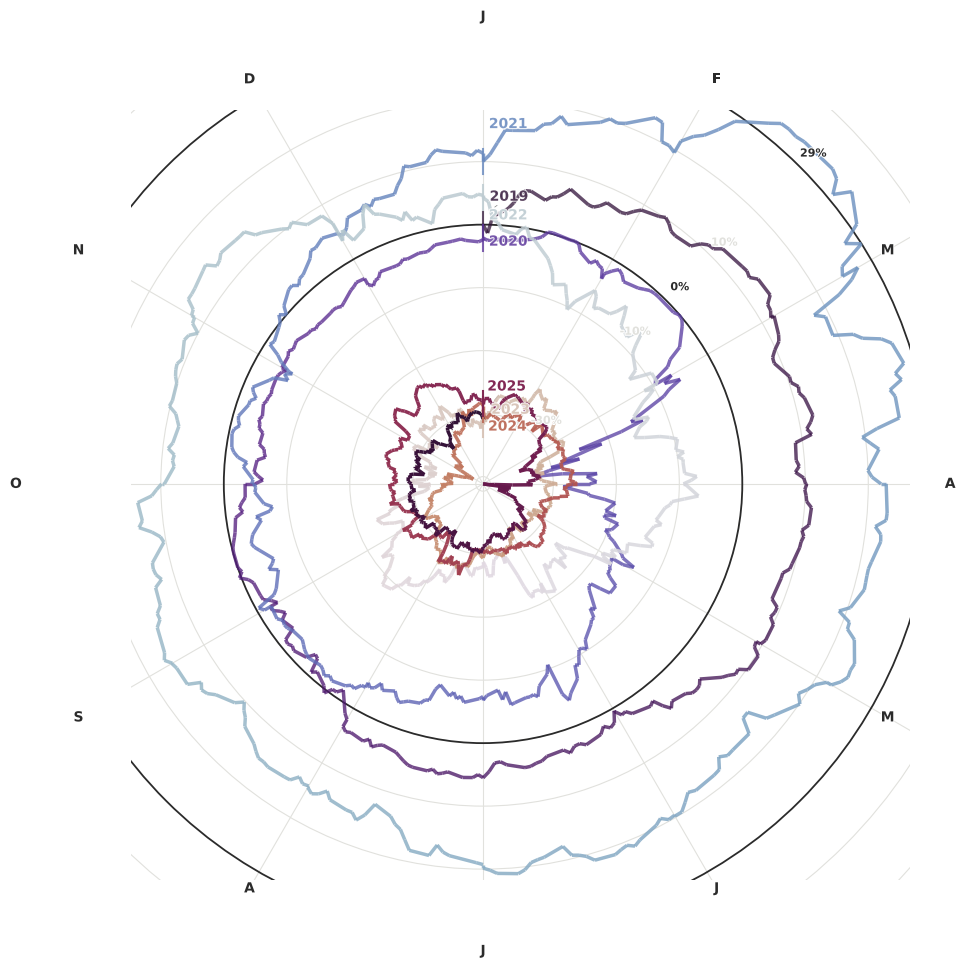

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from adjustText import adjust_text
import matplotlib.patheffects as path_effects

minor_line_settings = ("#E1E1DD", 0.8, 1, "-") # color, linewidth, alpha, style
major_line_settings = ("#2b2b2b", 1.3, 1, "-") # color, linewidth, alpha, style
data_line_settings = ("twilight_shifted", 2.5, (0.75, 1), "-") # cmap, linewidth, (alpha_min, alpha_max), style
text_outline_settings = ("white", 1.5) # color, linewidth


# 1. Generate sample data (a spiral)
x = df["x"]
y = df["y"]
z = df["cont_time"]  # The values used for coloring



# 2. Prepare the segments (reshape points into[N, 1, 2] array)
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# 2. Setup the colormap and normalization
cmap = plt.get_cmap(data_line_settings[0]) # Ensure this matches your LineCollection
norm = plt.Normalize(df['cont_time'].min(), df['cont_time'].max())

# 3. Create the LineCollection
fig, ax = plt.subplots()
fig.set_figheight(10)
fig.set_figwidth(13)

def scale_to_range(arr, new_min=0.5, new_max=1.0):
    arr = np.array(arr)
    # Calculate min and max of the input array
    old_min = arr.min()
    old_max = arr.max()
    
    # Avoid division by zero if all values are the same
    if old_max == old_min:
        return np.full_like(arr, (new_min + new_max) / 2)
    
    # Apply the formula
    return new_min + (arr - old_min) * (new_max - new_min) / (old_max - old_min)

rgba_values = cmap(norm(df['cont_time']))
rgba_values[:, 3] = scale_to_range(df['cont_time'], new_min=data_line_settings[2][0], new_max=data_line_settings[2][1])

# lc = LineCollection(segments, cmap=cmap, norm=norm)
lc = LineCollection(segments, colors=rgba_values)
# lc.set_array(z)
lc.set_linewidth(data_line_settings[1])

# 4. Add to plot
line = ax.add_collection(lc)
# fig.colorbar(line, ax=ax)
ax.set_xlim(x.min()-1, x.max()+1)
ax.set_ylim(y.min()-1, y.max()+1)


# 4. Annotate the first occurrence of each year
# Find the index of the first row for every unique year
first_year_indices = df.drop_duplicates(subset='year', keep='first').index

texts = list()

for idx in first_year_indices:
    year = df.loc[idx, 'year']
    val = df.loc[idx, 'cont_time']
    x_pos = df.loc[idx, 'x']
    x_pos_text = df.loc[idx, 'x']+1.5
    y_pos = df.loc[idx, 'y']
    y_pos_text= df.loc[idx+3, 'y']
    alpha = rgba_values[:, 3][idx]

    point_color = cmap(norm(val))

    tick_length = 4
    ax.plot([x_pos, x_pos],[y_pos - tick_length/2, y_pos + tick_length/2], 
            color=point_color, lw=1.5, zorder=10, alpha=alpha)
    
    t = ax.text(
        x_pos_text, y_pos_text, 
        str(year), 
        color=point_color,
        fontsize=10, 
        fontweight='bold',
        alpha=alpha
    )

    # Add the outline (Stroke) and the original text (Normal)
    t.set_path_effects([
        path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]),
        path_effects.Normal()
    ])
    texts.append(t)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))


# 1. Calculate the maximum distance to determine the scale
max_dist = df['distance_from_center'].max()

angles = list(month_to_degree.values())


def rotate_vector(vector, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))
    return vector @ R.T


# 2. Define the radii for your concentric circles
# We want circles at 20%, 40%, 60%, 80%, and 100% of the maximum radius
bar_spacing_percent = 10
radii = np.arange(-round(shift_zero,-1), round(max_dist, -1), bar_spacing_percent) + shift_zero # Can be negative so change this because if negative it gets converted to positive and does a ring where we don't want it
radii = radii[radii > 0] # Remove negative radii
raddi_to_idx = {r: i for i, r in enumerate(radii)}

# Loop through each angle to plot individual lines, the "axis" lines
month_texts = []
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ring_num = raddi_to_idx[round(df[df["x"] == 0]["y"].max(), -1) + shift_zero] - 2

for i, angle in enumerate(angles):
    # 1. Define the start (center) and end point
    start_point = np.array([0, 0])
    end_point = rotate_vector(np.array([0, radii[-1]+2]), -angle)
    
    # 2. Plot the line
    # X coordinates:[start_x, end_x], Y coordinates: [start_y, end_y]
    ax.plot([start_point[0], end_point[0]], 
            [start_point[1], end_point[1]], 
            color=minor_line_settings[0], alpha=minor_line_settings[2], lw=minor_line_settings[1], linestyle=minor_line_settings[3], zorder=0)
    
    text_point = rotate_vector(np.array([0, radii[ring_num]+3]), -angle)
    
    t = ax.text(
        text_point[0], text_point[1], 
        str(months[i]), 
        color=major_line_settings[0],
        fontsize=10, 
        fontweight='bold',
        alpha=major_line_settings[2],
        ha='center',
        va='center',
    )
    t.set_path_effects([
        path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]),
        path_effects.Normal()
    ])
    month_texts.append(t)

# Add percentage labels for the rings
for i, r in enumerate(radii[:ring_num+2]):
    x, y = rotate_vector(np.array([0, r+3]), -angles[2]+angles[1]/2) # Rotate the point on the y-axis to align with the first month line
    label = f"{int((r - shift_zero))}%"
    if (r == 0 + shift_zero) or i == ring_num: # Skip the zero point and the month ring
        t = ax.text(
        x, y, 
        label, 
        color=major_line_settings[0],
        fontsize=8, 
        fontweight='bold',
        alpha=major_line_settings[2],
        ha='center',
        va='center',
        )
    elif i % 2 == 0:
        continue
    else:
        t = ax.text(
            x, y, 
            label, 
            color=minor_line_settings[0],
            fontsize=8, 
            fontweight='bold',
            alpha=minor_line_settings[2],
            ha='center',
            va='center',
        )
    t.set_path_effects([
        path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]),
        path_effects.Normal()
    ])
    
# 3. Add circles to the plot
for i, r in enumerate(radii):
    if r == radii[ring_num]: # This is the month ring
        circle = plt.Circle(
            (0, 0),             # Center at the origin (0,0)
            r,                  # Radius
            color=major_line_settings[0],       # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle=major_line_settings[3],     # Dashed line style
            linewidth=major_line_settings[1],        # Thickness of the ring
            alpha=major_line_settings[2],          # Transparency
            zorder=0            # Put behind the data line
        )
        ax.add_patch(circle)
    else: # These are the minor rings
        circle = plt.Circle(
            (0, 0),             # Center at the origin (0,0)
            r,                  # Radius
            color=minor_line_settings[0],       # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle=minor_line_settings[3],     # Dashed line style
            linewidth=minor_line_settings[1],        # Thickness of the ring
            alpha=minor_line_settings[2],          # Transparency
            zorder=0            # Put behind the data line
        )
        ax.add_patch(circle)

circle = plt.Circle(            # Zero point ring
            (0, 0),             # Center at the origin (0,0)
            shift_zero,         # Radius
            color=major_line_settings[0],      # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle=major_line_settings[3],      # Normal line style
            linewidth=major_line_settings[1],        # Thickness of the ring
            alpha=major_line_settings[2],          # Transparency
            zorder=0            # Put behind the data line
        )
ax.add_patch(circle)

# 5. Final adjustments
ax.autoscale_view()
ax.set_aspect('equal') # Important for spiral/radial plots
ax.axis('off') 
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from adjustText import adjust_text
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation

# --- Settings ---
minor_line_settings = ("#E1E1DD", 0.8, 1, "-") 
major_line_settings = ("#2b2b2b", 1.3, 1, "-") 
data_line_settings = ("twilight_shifted", 2.5, (0.75, 1), "-") 
text_outline_settings = ("white", 1.5) 
step = 1  # Step through frames to set animation speed
color_base = df["change_day"]
red = "red"
green = "green"
facecolor ='#F7F5F0'

# Dynamic color settings
GREY_COLOR_RGB = mcolors.to_rgb("#E1E1DD")  # The target grey color (R, G, B)
WINDOW_SIZE = 300                    # The sliding window in days/rows

# --- 1. Prepare Data ---
x = df["x"].values
y = df["y"].values
z = color_base.values

# Reshape points for LineCollection
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

colors_list = [red, "darkgray", green]
cmap = mcolors.LinearSegmentedColormap.from_list("RdGrGn", colors_list)

# cmap = plt.get_cmap(data_line_settings[0])
norm = mcolors.CenteredNorm(halfrange=2)

def scale_to_range(arr, new_min=0.5, new_max=1.0):
    arr = np.array(arr)
    old_min = arr.min()
    old_old = arr.max()
    if old_old == old_min:
        return np.full_like(arr, (new_min + new_max) / 2)
    return new_min + (arr - old_min) * (new_max - new_min) / (old_old - old_min)

rgba_values = cmap(norm(color_base))
rgba_values[:, 3] = scale_to_range(color_base, new_min=data_line_settings[2][0], new_max=data_line_settings[2][1])
segment_colors = rgba_values[:-1]

# --- 2. Setup Figure and Axes ---
fig, ax = plt.subplots(figsize=(13, 10), facecolor=facecolor)

# Create a small, narrow axis on the right side for the dynamic bar
# Position format: [left, bottom, width, height] in figure coordinates
ax_bar = fig.add_axes([0.88, 0.25, 0.03, 0.5], facecolor=facecolor )

# --- 3. Draw Static Background Elements ---
max_dist = df['distance_from_center'].max()
angles = list(month_to_degree.values())

def rotate_vector(vector, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))
    return vector @ R.T

radii = np.arange(-round(shift_zero, -1), round(max_dist, -1), 10) + shift_zero
radii = radii[radii > 0]
raddi_to_idx = {r: i for i, r in enumerate(radii)}

month_texts = []
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ring_num = raddi_to_idx[round(df[df["x"] == 0]["y"].max(), -1) + shift_zero] - 2

last_ring = -2

for i, angle in enumerate(angles):
    start_point = np.array([0, 0])
    end_point = rotate_vector(np.array([0, radii[last_ring-1]+2]), -angle)
    
    ax.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]], 
            color=minor_line_settings[0], alpha=minor_line_settings[2], 
            lw=minor_line_settings[1], linestyle=minor_line_settings[3], zorder=0)
    
    text_point = rotate_vector(np.array([0, radii[ring_num]+3]), -angle)
    
    t = ax.text(text_point[0], text_point[1], str(months[i]), color=major_line_settings[0],
                fontsize=10, fontweight='bold', alpha=major_line_settings[2], ha='center', va='center')
    t.set_path_effects([path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]), path_effects.Normal()])
    month_texts.append(t)

for i, r in enumerate(radii[:ring_num+2]):
    x_val, y_val = rotate_vector(np.array([0, r+3]), -angles[2]+angles[1]/2)
    label = f"{int(round(r - shift_zero))}%"
    if (r == 0 + shift_zero) or i == ring_num: # zero line and last line
        t = ax.text(x_val, y_val, label, color=major_line_settings[0], fontsize=8, fontweight='bold',
                    alpha=major_line_settings[2], ha='center', va='center')
    elif i % 2 == 0:
        continue
    else:
        t = ax.text(x_val, y_val, label, color=minor_line_settings[0], fontsize=8, fontweight='bold',
                    alpha=minor_line_settings[2], ha='center', va='center')
    t.set_path_effects([path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]), path_effects.Normal()])
    
for i, r in enumerate(radii[:last_ring]):
    use_major = (r == radii[ring_num])
    circle = plt.Circle((0, 0), r, color=major_line_settings[0] if use_major else minor_line_settings[0],
                        fill=False, linestyle=major_line_settings[3] if use_major else minor_line_settings[3],
                        linewidth=major_line_settings[1] if use_major else minor_line_settings[1],
                        alpha=major_line_settings[2] if use_major else minor_line_settings[2], zorder=0)
    ax.add_patch(circle)

circle = plt.Circle((0, 0), shift_zero, color=major_line_settings[0], fill=False,
                    linestyle=major_line_settings[3], linewidth=major_line_settings[1],
                    alpha=major_line_settings[2], zorder=0)
ax.add_patch(circle)

# --- 4. Initialize Animated LineCollection ---
lc = LineCollection(segments[0:0], colors=segment_colors[0:0])
lc.set_linewidth(data_line_settings[1])
ax.add_collection(lc)

# --- 5. Prepare Year Annotations ---
first_year_indices = df.drop_duplicates(subset='year', keep='first').index
texts = []
annotation_objects = []

children_before = set(ax.get_children())

for idx in first_year_indices:
    year = df.loc[idx, 'year']
    val = df.loc[idx, "change_year"]
    x_pos = df.loc[idx, 'x']
    x_pos_text = df.loc[idx, 'x'] + 1.5
    y_pos = df.loc[idx, 'y']
    y_pos_text = df.loc[idx+3, 'y'] if (idx+3) in df.index else df.loc[idx, 'y']
    alpha = rgba_values[:, 3][idx]
    point_color = cmap(norm(val))

    tick_length = 4
    tick_line, = ax.plot([x_pos, x_pos], [y_pos - tick_length/2, y_pos + tick_length/2], 
                         color=point_color, lw=1.5, zorder=10, alpha=alpha)
    
    t = ax.text(x_pos_text, y_pos_text, str(year), color=point_color, fontsize=10, fontweight='bold', alpha=alpha)
    t.set_path_effects([path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]), path_effects.Normal()])
    
    texts.append(t)
    annotation_objects.append({'idx': idx, 'tick': tick_line, 'text': t, 'arrow': None})

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

children_after = set(ax.get_children())
new_artists = children_after - children_before

for artist in new_artists:
    try:
        path = artist.get_path()
        vertices = path.vertices
        best_annot = None
        min_dist = float('inf')
        for ann in annotation_objects:
            tx, ty = ann['text'].get_position()
            dist = np.min(np.sum((vertices - np.array([tx, ty]))**2, axis=1))
            if dist < min_dist:
                min_dist = dist
                best_annot = ann
        if best_annot is not None and min_dist < 50:
            best_annot['arrow'] = artist
    except Exception:
        pass

for ann in annotation_objects:
    ann['tick'].set_visible(False)
    ann['text'].set_visible(False)
    if ann['arrow'] is not None:
        ann['arrow'].set_visible(False)

# --- 6. Set Limits and View ---
outer_limit = radii[last_ring-1]
ax.set_xlim(-outer_limit, outer_limit)
ax.set_ylim(-outer_limit, outer_limit)
ax.set_aspect('equal')
ax.axis('off')
fig.subplots_adjust(left=0.01, right=0.84, top=0.98, bottom=0.02)

# --- 6.1 Configure Side Bar (Change %) ---
bar_data = df["close (%)"].values
max_abs_val = max(abs(bar_data.min()), abs(bar_data.max()))

# Format bar axis bounds and aesthetics
ax_bar.set_xlim(-0.8, 1.2)
ax_bar.set_ylim(-max_abs_val * 1.15, max_abs_val * 1.15)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['bottom'].set_visible(False)
ax_bar.get_xaxis().set_visible(False)
ax_bar.tick_params(axis='y', labelsize=8, colors=minor_line_settings[0])
ax_bar.set_title("Change (%)", fontsize=10, fontweight='bold', color=minor_line_settings[0], pad=10)

# Zero reference line
ax_bar.axhline(0, color=minor_line_settings[0], linewidth=0.8, linestyle=major_line_settings[3], zorder=1)

# Initialize dynamic bar, range markers, and labels
bar_rect = ax_bar.bar(0, 0, width=0.4, color=major_line_settings[0], zorder=2)[0]
line_min, = ax_bar.plot([-0.3, 0.3], [0, 0], color=red, linestyle=major_line_settings[3], linewidth=major_line_settings[1], zorder=3)
line_max, = ax_bar.plot([-0.3, 0.3], [0, 0], color=green, linestyle=major_line_settings[3], linewidth=major_line_settings[1], zorder=3)

# Static layout text containers to display numerical values alongside markers
text_min = ax_bar.text(0.35, 0, '', color=red, fontsize=8, fontweight='bold', va='center', ha='left')
text_max = ax_bar.text(0.35, 0, '', color=green, fontsize=8, fontweight='bold', va='center', ha='left')
text_val = ax_bar.text(0, 0, '', color=major_line_settings[0], fontsize=9, fontweight='bold', va='bottom', ha='center')

# --- 7. Helper Function for Dynamic Coloring ---
def get_dynamic_colors(frame, base_colors, grey_rgb, window):
    current_colors = base_colors[:frame].copy()
    if frame == 0:
        return current_colors
    
    start_idx = max(0, frame - window)
    if start_idx > 0:
        current_colors[:start_idx, :3] = grey_rgb
        
    gradient_len = frame - start_idx
    if gradient_len > 0:
        factors = np.linspace(0, 1, gradient_len).reshape(-1, 1)
        original_rgb = current_colors[start_idx:frame, :3]
        blended_rgb = (1 - factors) * np.array(grey_rgb) + factors * original_rgb
        current_colors[start_idx:frame, :3] = blended_rgb
        
    return current_colors

# --- 8. Animation Functions ---
def update(frame):
    current_segments = segments[:frame]
    
    # Generate the sliding dynamic colors for this frame
    current_colors = get_dynamic_colors(
        frame=frame, 
        base_colors=segment_colors, 
        grey_rgb=GREY_COLOR_RGB, 
        window=WINDOW_SIZE
    )
    
    lc.set_segments(current_segments)
    lc.set_colors(current_colors[1:])
    
    # Update side bar statistics
    idx = min(frame, len(bar_data) - 1)
    current_val = bar_data[idx]
    
    
    # Compute running historical boundaries up to current frame
    historical_subset = bar_data[:idx + 1]
    hist_min = historical_subset.min()
    hist_min_idx = historical_subset.argmin()
    hist_max = historical_subset.max()
    hist_max_idx = historical_subset.argmax()
    
    # Update the bar metrics
    bar_rect.set_height(current_val)
    bar_rect.set_color(cmap(norm(current_val)))
    
    # Position and adjust horizontal threshold lines
    line_min.set_ydata([hist_min, hist_min])
    line_max.set_ydata([hist_max, hist_max])
    
    # Update text values next to thresholds
    text_min.set_position((0.35, hist_min))
    text_min.set_text(f"Min\n{hist_min:+.1f}%\n{df.loc[hist_min_idx, "report_date"].strftime("%d/%m/%Y")}")
    
    text_max.set_position((0.35, hist_max))
    text_max.set_text(f"Max\n{hist_max:+.1f}%\n{df.loc[hist_max_idx, "report_date"].strftime("%d/%m/%Y")}")
    
    text_val.set_position((0, current_val))
    text_val.set_text(f"{current_val:+.1f}%")
    text_val.set_va('bottom' if current_val >= 0 else 'top')
    
    # Toggle year markers
    for ann in annotation_objects:
        is_visible = (frame >= ann['idx'])
        ann['tick'].set_visible(is_visible)
        ann['text'].set_visible(is_visible)
        if ann['arrow'] is not None:
            ann['arrow'].set_visible(is_visible)

# Configure the animation steps
frames_indices = list(range(1, len(segments) + 1, step))
if frames_indices[-1] != len(segments):
    frames_indices.append(len(segments))

# Ensure that we allow larger embedding sizes in Jupyter
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 100.0  

ani = FuncAnimation(
    fig, update, 
    frames=frames_indices, 
    interval=20, 
    blit=False, 
    repeat=False
)

# --- 9. Display in Jupyter ---
from IPython.display import HTML
plt.close(fig) 
HTML(ani.to_html5_video())

In [189]:
df

,report_date,close (%),close,change_day,close_1yr_ago,close_1mo_ago,change_year,change_month,month,day,month_rotation,year,day_degrees,distance_from_center,x,y,cont_time
0,2019-01-02,0.000000,74.174000,0.000000,NaN,NaN,NaN,NaN,1,2,0,2019,0.000000,41.157068,0.000000e+00,41.157068,0
1,2019-01-03,-1.334553,73.184108,-0.989891,NaN,NaN,NaN,NaN,1,3,0,2019,1.034483,39.822515,7.189616e-01,39.816025,1
2,2019-01-04,1.270367,75.116281,1.932173,NaN,NaN,NaN,NaN,1,4,0,2019,2.068966,42.427435,1.531733e+00,42.399776,2
3,2019-01-07,2.708221,76.182796,1.066514,NaN,NaN,NaN,NaN,1,7,0,2019,5.172414,43.865290,3.954591e+00,43.686667,3
4,2019-01-08,3.702307,76.920149,0.737353,NaN,NaN,NaN,NaN,1,8,0,2019,6.206897,44.859375,4.850152e+00,44.596407,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1755,2025-12-24,-29.647111,52.183552,0.171267,54.166147,50.329600,-1.982596,1.853952,12,24,330,2025,353.000000,11.509957,-1.402711e+00,11.424164,1755
1756,2025-12-26,-29.685905,52.154776,-0.028775,54.250469,51.484675,-2.095692,0.670101,12,26,330,2025,355.000000,11.471163,-9.997777e-01,11.427512,1756
1757,2025-12-29,-29.986823,51.931574,-0.223203,53.695533,51.705985,-1.763959,0.225588,12,29,330,2025,358.000000,11.170245,-3.898359e-01,11.163440,1757
1758,2025-12-30,-30.270865,51.720889,-0.210685,53.504532,51.705985,-1.783643,0.014903,12,30,330,2025,359.000000,10.886203,-1.899904e-01,10.884545,1758


In [190]:
df.iloc[252]

report_date             2020-01-02 00:00:00
close (%)                         -2.112209
close                             72.607289
change_day                         0.201751
close_1yr_ago                        74.174
close_1mo_ago                     70.733763
change_year                        -1.56671
change_month                       1.873527
month                                     1
day                                       2
month_rotation                            0
year                                   2020
day_degrees                             0.0
distance_from_center              39.044859
x                                       0.0
y                                 39.044859
cont_time                               252
Name: 252, dtype: object

In [191]:
# fig.savefig("figs/spiral_test_2.png", dpi=300, bbox_inches="tight")
# fig.savefig("figs/spiral_test_2.pdf", bbox_inches="tight")